# Drug Type Prediction Using Decision Tree

A machine learning approach to classify patients and predict the most effective drug based on medical and demographic data.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv(r'/content/drug200.csv')
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


# Data Exploration

This section explores the dataset in depth to understand variable distributions, relationships, and potential predictors of insurance fraud. Through univariate, bivariate, and multivariate analyses, key patterns and correlations are identified. Statistical tools such as VIF, correlation heatmaps, and hierarchical clustering are used to detect multicollinearity and redundancy.
Based on these insights, non-informative or overlapping variables are removed, resulting in a refined set of independent, meaningful features ready for logistic regression modeling.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [4]:
df.dtypes.value_counts()

,count
object,4
int64,1
float64,1


In [5]:
print("Dataset shape:", df.shape)

Dataset shape: (200, 6)


In [6]:
print(df.isnull().any(axis=0))


Age            False
Sex            False
BP             False
Cholesterol    False
Na_to_K        False
Drug           False
dtype: bool


In [7]:
from sklearn.preprocessing import LabelEncoder

df_numeric = df.copy()

target_col = 'Drug'
categorical_cols = df_numeric.drop(columns=[target_col]).select_dtypes(include='object').columns

le = LabelEncoder()
for col in categorical_cols:
    df_numeric[col] = le.fit_transform(df_numeric[col])

target_le = LabelEncoder()
df_numeric[target_col] = target_le.fit_transform(df_numeric[target_col])

df_numeric.head()


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,4
1,47,1,1,0,13.093,2
2,47,1,1,0,10.114,2
3,28,0,2,0,7.798,3
4,61,0,1,0,18.043,4


[Text(0, 0, '23'),
 Text(0, 0, '16'),
 Text(0, 0, '16'),
 Text(0, 0, '54'),
 Text(0, 0, '91')]

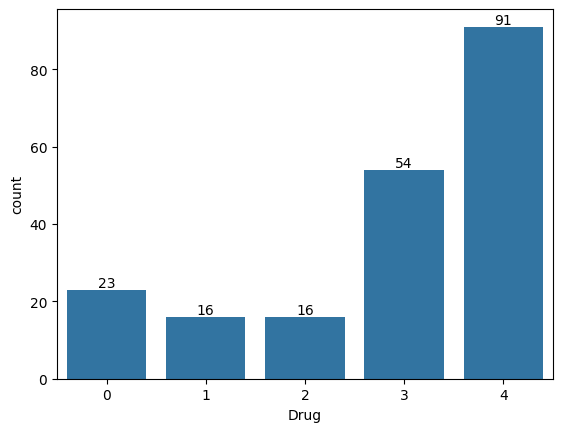

In [8]:
ax=sns.countplot(data=df_numeric, x='Drug');
ax.bar_label(ax.containers[0])

/tmp/ipython-input-2233033259.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(fontsize=8)
/tmp/ipython-input-2233033259.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(fontsize=8)


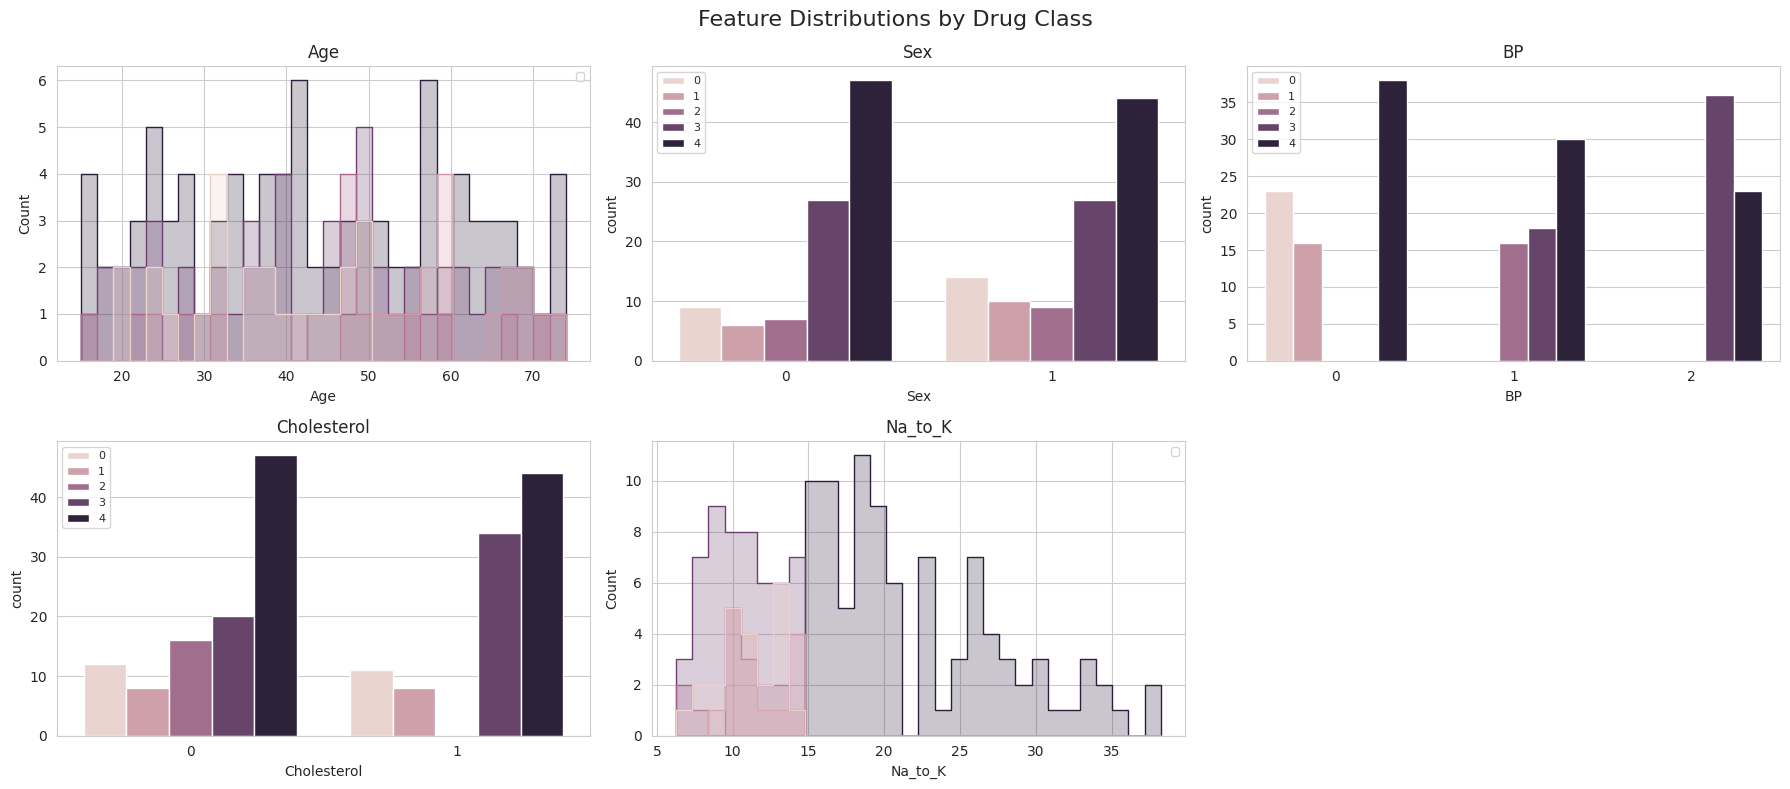

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_style("whitegrid")
sns.set_palette("tab10")

features = df_numeric.columns.drop('Drug')
num_features = len(features)
cols = 3
rows = math.ceil(num_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    if df_numeric[feature].nunique() <= 10:
        sns.countplot(data=df_numeric, x=feature, hue='Drug', ax=axes[i])
    else:
        sns.histplot(data=df_numeric, x=feature, hue='Drug', bins=30, ax=axes[i], element="step")

    axes[i].set_title(feature, fontsize=12)
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Feature Distributions by Drug Class", fontsize=16)
fig.tight_layout()
plt.show()


<Figure size 1500x1000 with 0 Axes>

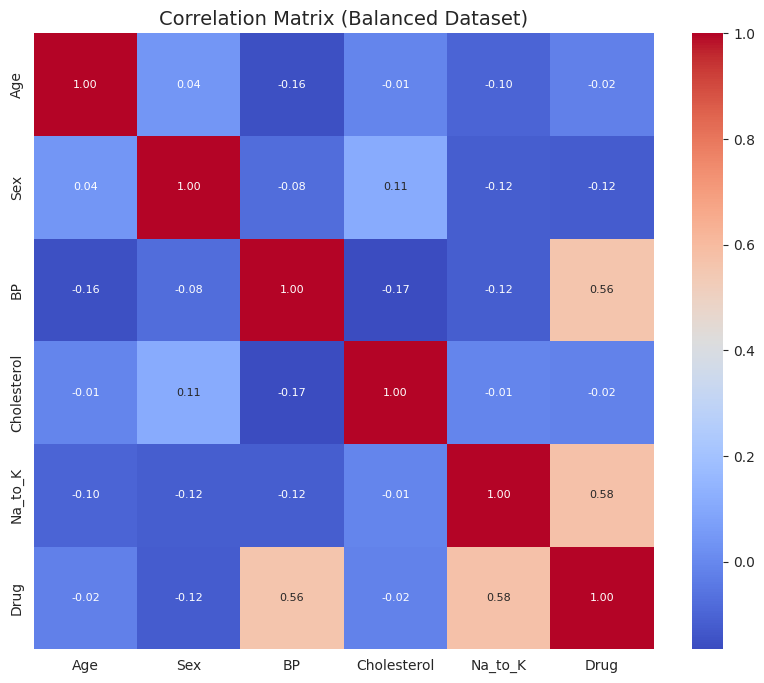

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

plt.figure(figsize=(15, 10))

X = df_numeric[df_numeric.columns[:-1]]
y = df_numeric["Drug"]

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

df_numeric_balanced = pd.concat(
    [pd.DataFrame(X_res, columns=df_numeric.columns[:-1]),
     pd.Series(y_res, name="Drug")],
    axis=1
)

corr = df_numeric_balanced.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, annot_kws={'size': 8}, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Balanced Dataset)", fontsize=14)
plt.show()


/tmp/ipython-input-2769214036.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')


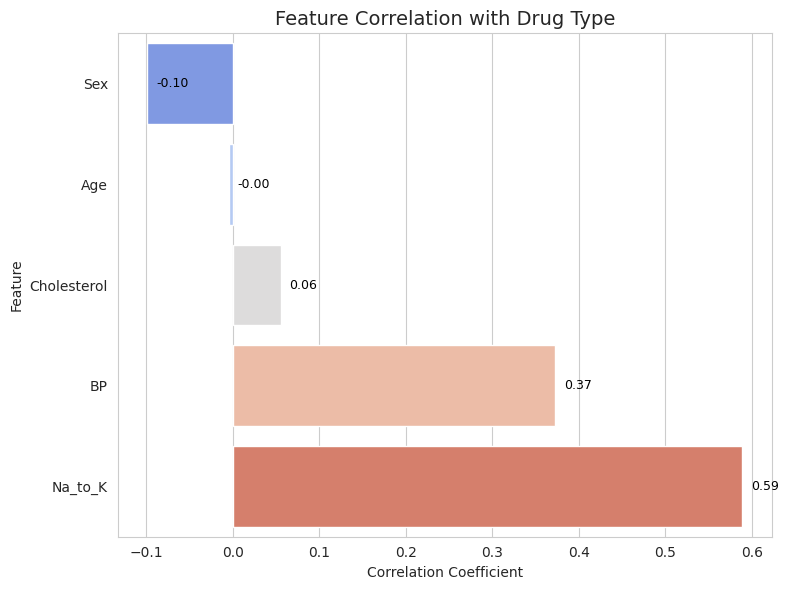

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

corr_target = df_numeric.corr()['Drug'].drop('Drug').sort_values(ascending=True)

sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')

for i, v in enumerate(corr_target.values):
    plt.text(v + 0.01, i, f"{v:.2f}", va='center', fontsize=9, color='black')

plt.title("Feature Correlation with Drug Type", fontsize=14)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Feature Adding

In [12]:
df_fe = df_numeric.copy()

df_fe['Na_to_K_bin'] = pd.cut(df_fe['Na_to_K'], bins=[0, 10, 20, 30, 40],
                              labels=['Low', 'Medium', 'High', 'Very High'])
df_fe['Age_Group'] = pd.cut(df_fe['Age'], bins=[0, 30, 50, 70, 100],
                            labels=['Young', 'Adult', 'Senior', 'Elderly'])
df_fe['BP_Cholesterol'] = df_fe['BP'] * df_fe['Cholesterol']
df_fe['NaK_BP'] = df_fe['Na_to_K'] * df_fe['BP']


In [13]:
df_fe

,Age,Sex,BP,Cholesterol,Na_to_K,Drug,Na_to_K_bin,Age_Group,BP_Cholesterol,NaK_BP
0,23,0,0,0,25.355,4,High,Young,0,0.000
1,47,1,1,0,13.093,2,Medium,Adult,0,13.093
2,47,1,1,0,10.114,2,Medium,Adult,0,10.114
3,28,0,2,0,7.798,3,Low,Young,0,15.596
4,61,0,1,0,18.043,4,Medium,Senior,0,18.043
...,...,...,...,...,...,...,...,...,...,...
195,56,0,1,0,11.567,2,Medium,Senior,0,11.567
196,16,1,1,0,12.006,2,Medium,Young,0,12.006
197,52,1,2,0,9.894,3,Low,Senior,0,19.788
198,23,1,2,1,14.020,3,Medium,Young,2,28.040


In [14]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df_fe.copy()

new_cats = ['Na_to_K_bin', 'Age_Group']

le = LabelEncoder()
for col in new_cats:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))


/tmp/ipython-input-116799096.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(fontsize=8)
/tmp/ipython-input-116799096.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(fontsize=8)
/tmp/ipython-input-116799096.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(fontsize=8)


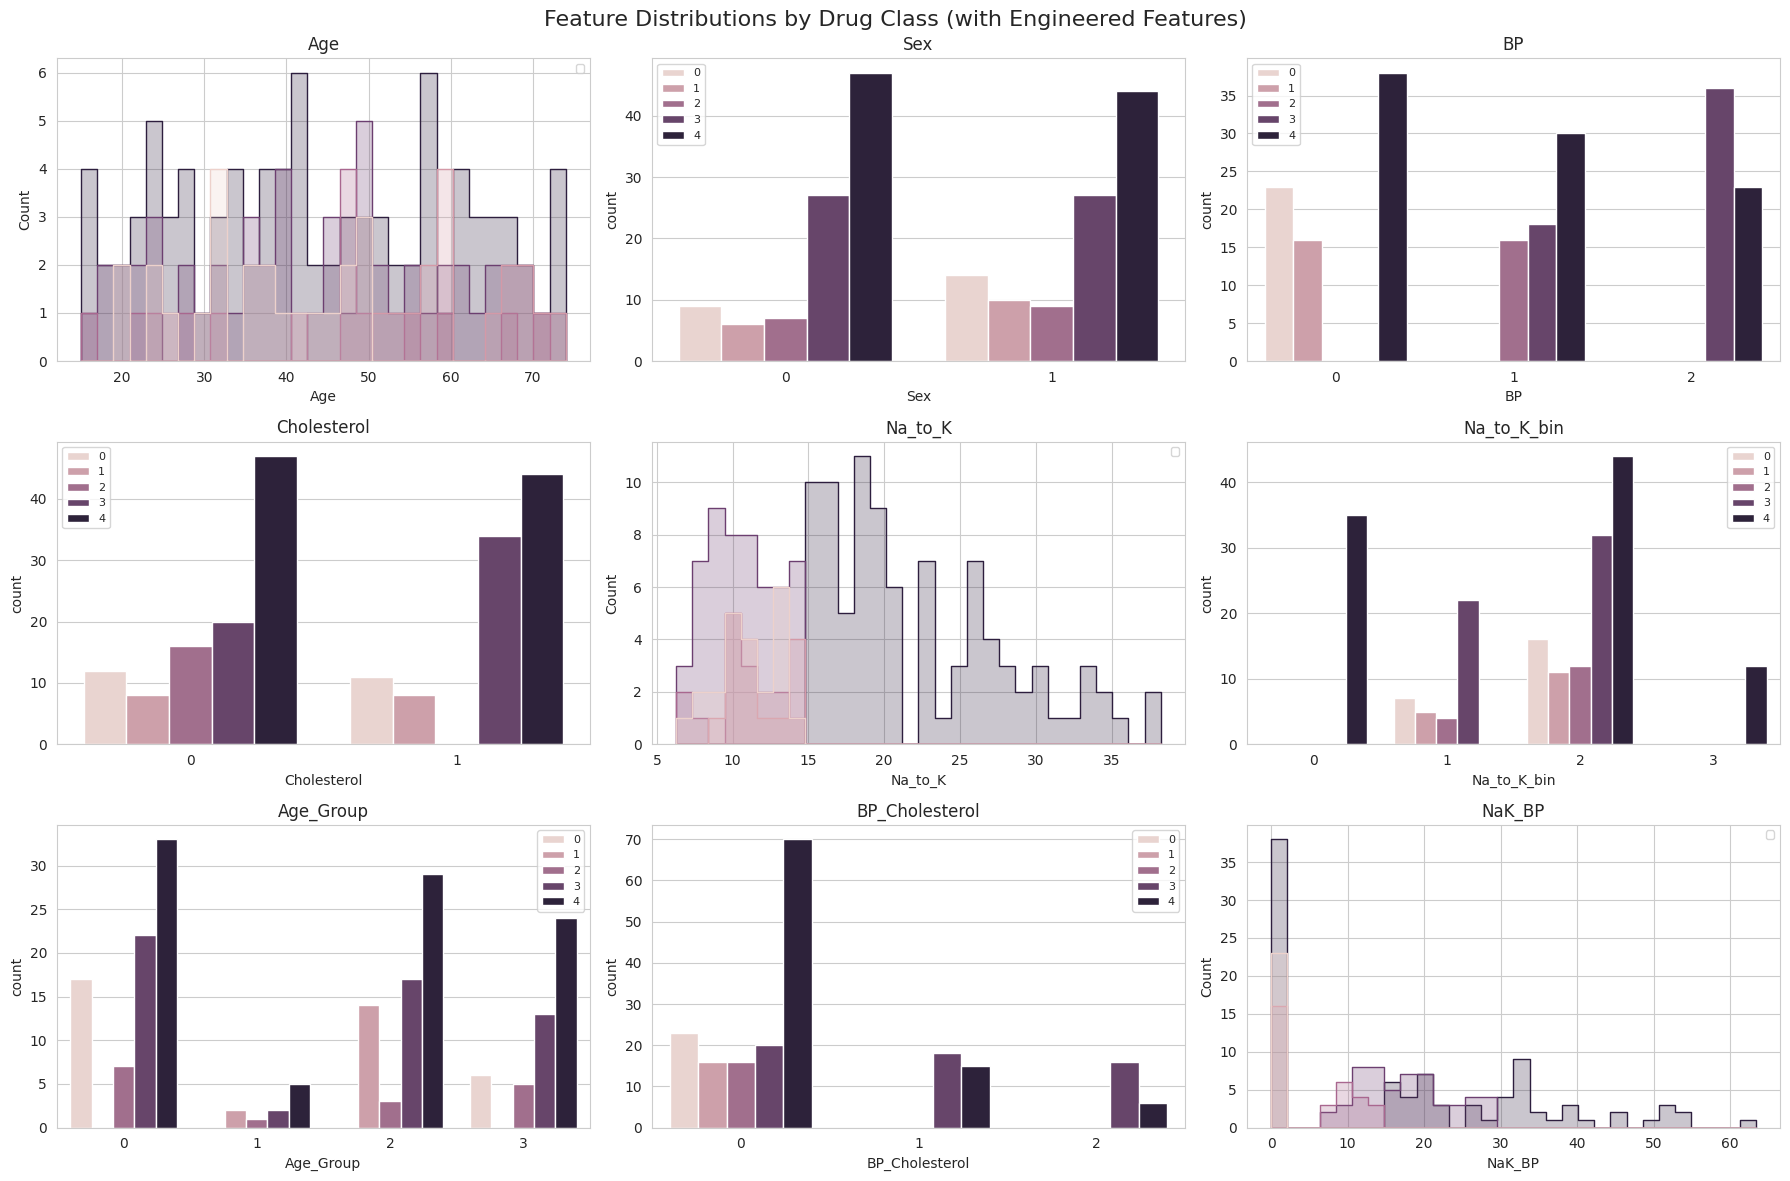

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_style("whitegrid")
sns.set_palette("tab10")

features = df_encoded.columns.drop('Drug')
num_features = len(features)

cols = 3
rows = math.ceil(num_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    if df_encoded[feature].nunique() <= 10:
        sns.countplot(data=df_encoded, x=feature, hue='Drug', ax=axes[i])
    else:
        sns.histplot(data=df_encoded, x=feature, hue='Drug', bins=30, ax=axes[i], element="step")

    axes[i].set_title(feature, fontsize=12)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Feature Distributions by Drug Class (with Engineered Features)", fontsize=16)
fig.tight_layout()
plt.show()


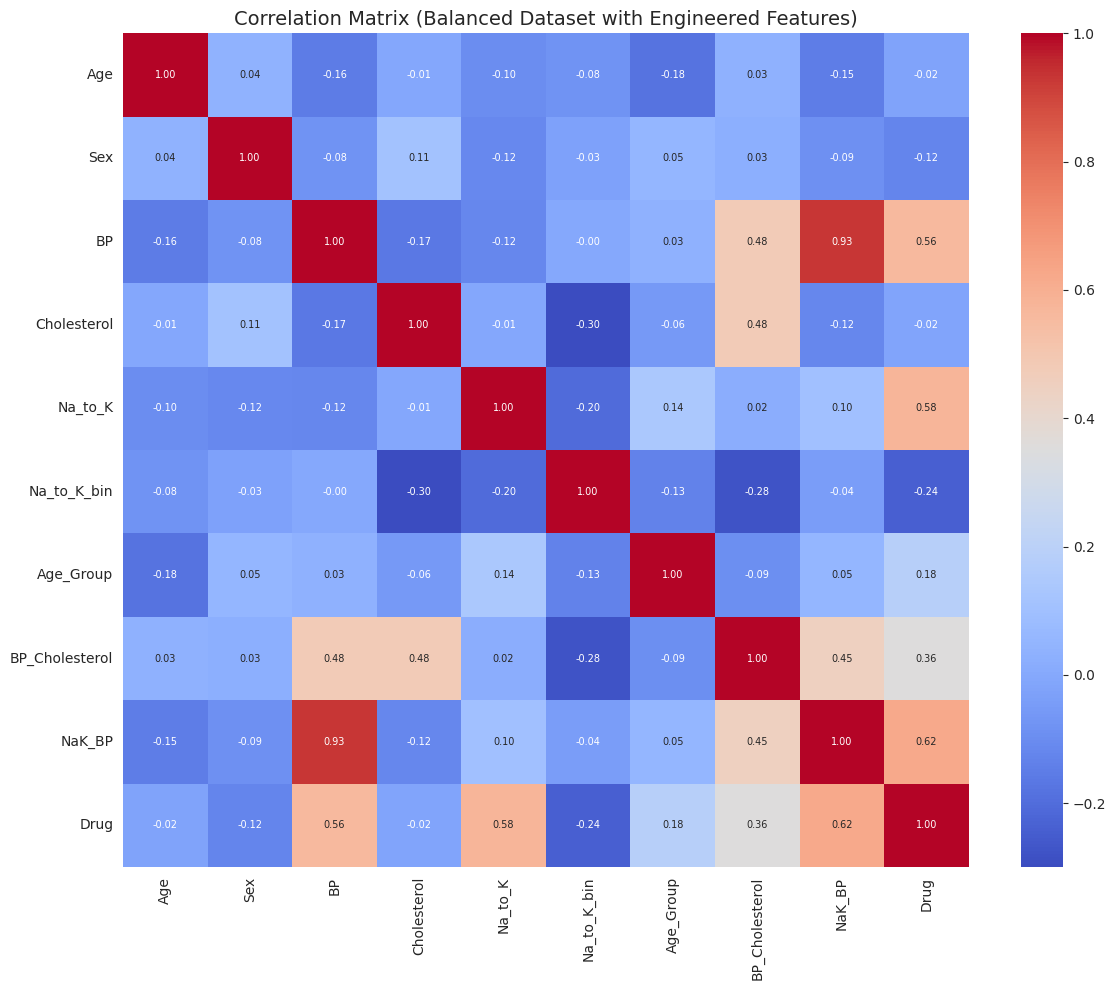

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

X = df_encoded.drop('Drug', axis=1)
y = df_encoded['Drug']

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

df_encoded_balanced = pd.concat(
    [pd.DataFrame(X_res, columns=X.columns),
     pd.Series(y_res, name='Drug')],
    axis=1
)

corr = df_encoded_balanced.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, annot_kws={'size': 7}, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Balanced Dataset with Engineered Features)", fontsize=14)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1870898115.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')


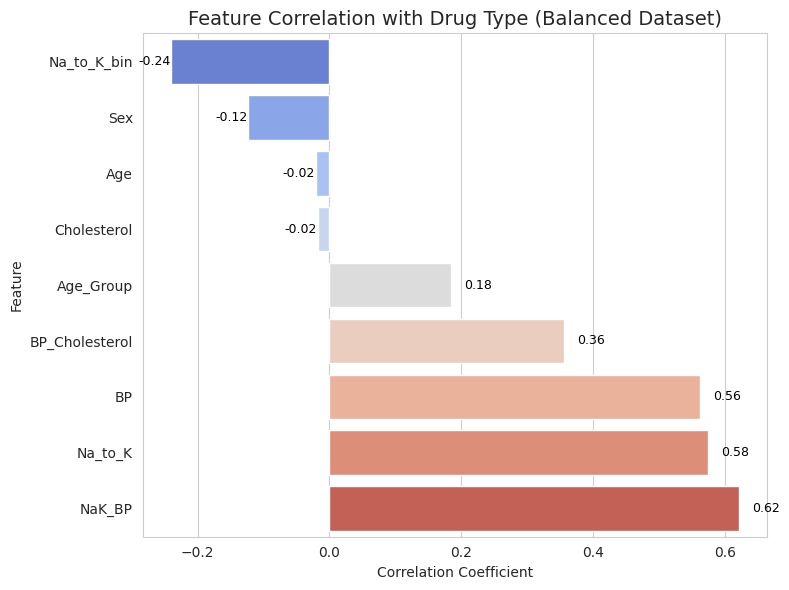

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

corr_target = (
    df_encoded_balanced.corr()['Drug']
    .drop('Drug')
    .sort_values(ascending=True)
)

sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')

for i, v in enumerate(corr_target.values):
    plt.text(v + (0.02 if v >= 0 else -0.05), i, f"{v:.2f}",
             va='center', fontsize=9, color='black')

plt.title("Feature Correlation with Drug Type (Balanced Dataset)", fontsize=14)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

X_vif = df_encoded_balanced.drop(columns=['Drug']).copy()
X_vif = add_constant(X_vif)

vif_data = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("Variance Inflation Factor (VIF) Results:")
print(vif_data)


Variance Inflation Factor (VIF) Results:
          Feature        VIF
0           const  56.864899
1              BP  15.187215
2          NaK_BP  12.510406
3  BP_Cholesterol   2.549705
4     Cholesterol   2.021099
5         Na_to_K   1.804601
6     Na_to_K_bin   1.233624
7             Age   1.150645
8       Age_Group   1.104061
9             Sex   1.042436


#Split

In [19]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Drug'])
y = df_encoded['Drug']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (160, 9)
Testing set size: (40, 9)


In [20]:
import time
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

param_dist = {
    'max_depth': randint(2, 10),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

def train_model(model, param_dist):
    start = time.time()

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    rand_search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=20,
        scoring='accuracy',
        cv=cv,
        random_state=42,
        n_jobs=-1
    )

    rand_search.fit(X_train, y_train)

    print("Best hyperparameters:", rand_search.best_params_)
    print(f"Training time: {time.time() - start:.2f} seconds")
    print(f"Best cross-validated accuracy: {rand_search.best_score_:.2f}")

    return rand_search.best_estimator_

model = train_model(dt, param_dist)


Best hyperparameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 3, 'min_samples_split': 4}
Training time: 3.19 seconds
Best cross-validated accuracy: 1.00


Macro-average ROC-AUC: 0.927
Weighted-average ROC-AUC: 0.968


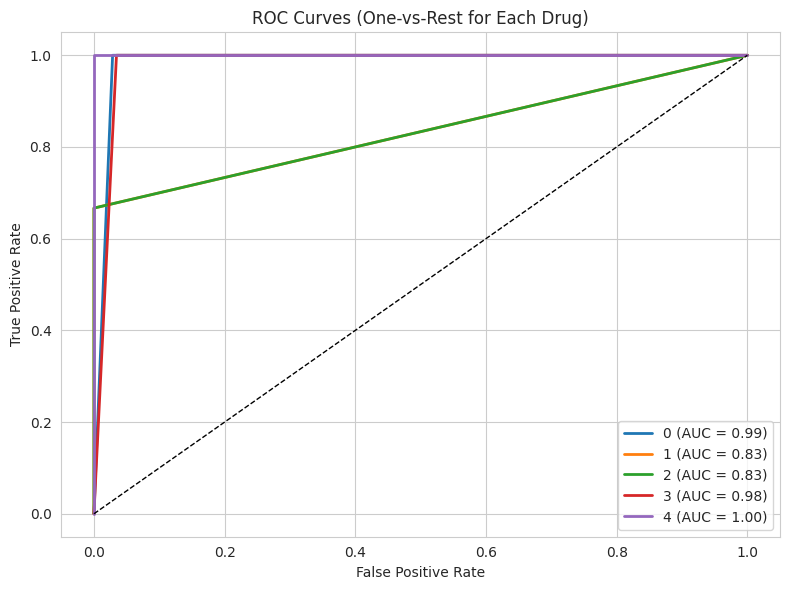

In [21]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

y_test_bin = label_binarize(y_test, classes=model.classes_)
y_pred_prob = model.predict_proba(X_test)

roc_auc_macro = roc_auc_score(y_test_bin, y_pred_prob, average='macro')
roc_auc_weighted = roc_auc_score(y_test_bin, y_pred_prob, average='weighted')

print(f"Macro-average ROC-AUC: {roc_auc_macro:.3f}")
print(f"Weighted-average ROC-AUC: {roc_auc_weighted:.3f}")

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(model.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, lw=2, label=f"{class_name} (AUC = {auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest for Each Drug)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


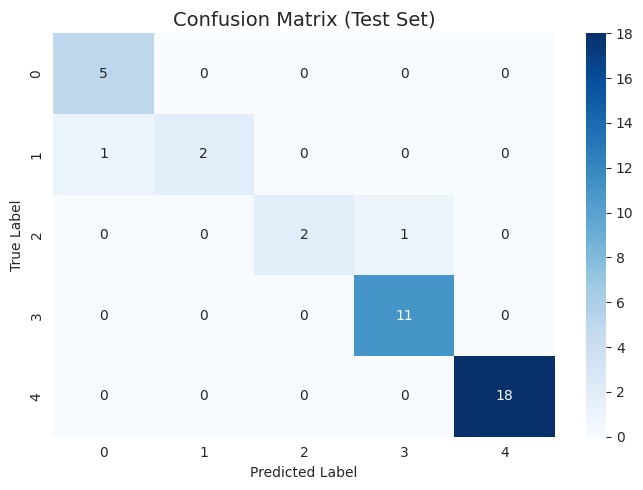

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix (Test Set)", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [23]:
from sklearn.metrics import f1_score, classification_report

f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"Macro F1-score: {f1_macro:.3f}")
print(f"Weighted F1-score: {f1_weighted:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Macro F1-score: 0.893
Weighted F1-score: 0.947

Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.67      0.80         3
           2       1.00      0.67      0.80         3
           3       0.92      1.00      0.96        11
           4       1.00      1.00      1.00        18

    accuracy                           0.95        40
   macro avg       0.95      0.87      0.89        40
weighted avg       0.96      0.95      0.95        40



/tmp/ipython-input-348516120.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")


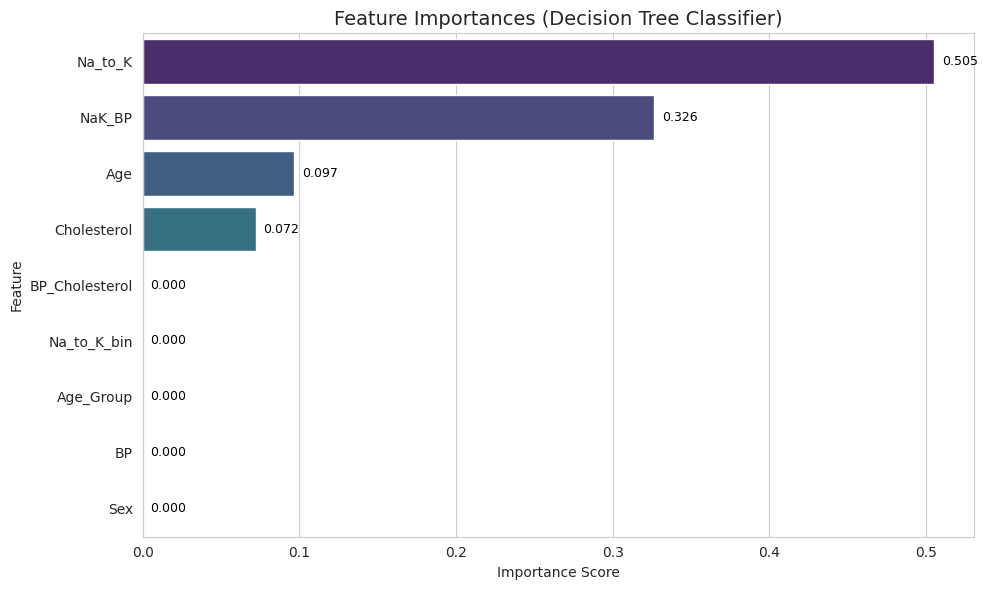


Feature Importance Ranking:
 1. Na_to_K              — 0.5050
 2. NaK_BP               — 0.3263
 3. Age                  — 0.0965
 4. Cholesterol          — 0.0721
 5. BP_Cholesterol       — 0.0000
 6. Na_to_K_bin          — 0.0000
 7. Age_Group            — 0.0000
 8. BP                   — 0.0000
 9. Sex                  — 0.0000


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importances(model, feature_names=None, top_n=None):

    importances = model.feature_importances_
    if feature_names is None:
        feature_names = model.feature_names_in_

    indices = np.argsort(importances)[::-1]
    sorted_features = np.array(feature_names)[indices]
    sorted_importances = importances[indices]

    if top_n:
        sorted_features = sorted_features[:top_n]
        sorted_importances = sorted_importances[:top_n]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")

    for i, val in enumerate(sorted_importances):
        plt.text(val + 0.005, i, f"{val:.3f}", va='center', fontsize=9, color='black')

    plt.title("Feature Importances (Decision Tree Classifier)", fontsize=14)
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    print("\nFeature Importance Ranking:")
    for i, (feat, imp) in enumerate(zip(sorted_features, sorted_importances), 1):
        print(f"{i:2d}. {feat:20s} — {imp:.4f}")

plot_feature_importances(model)


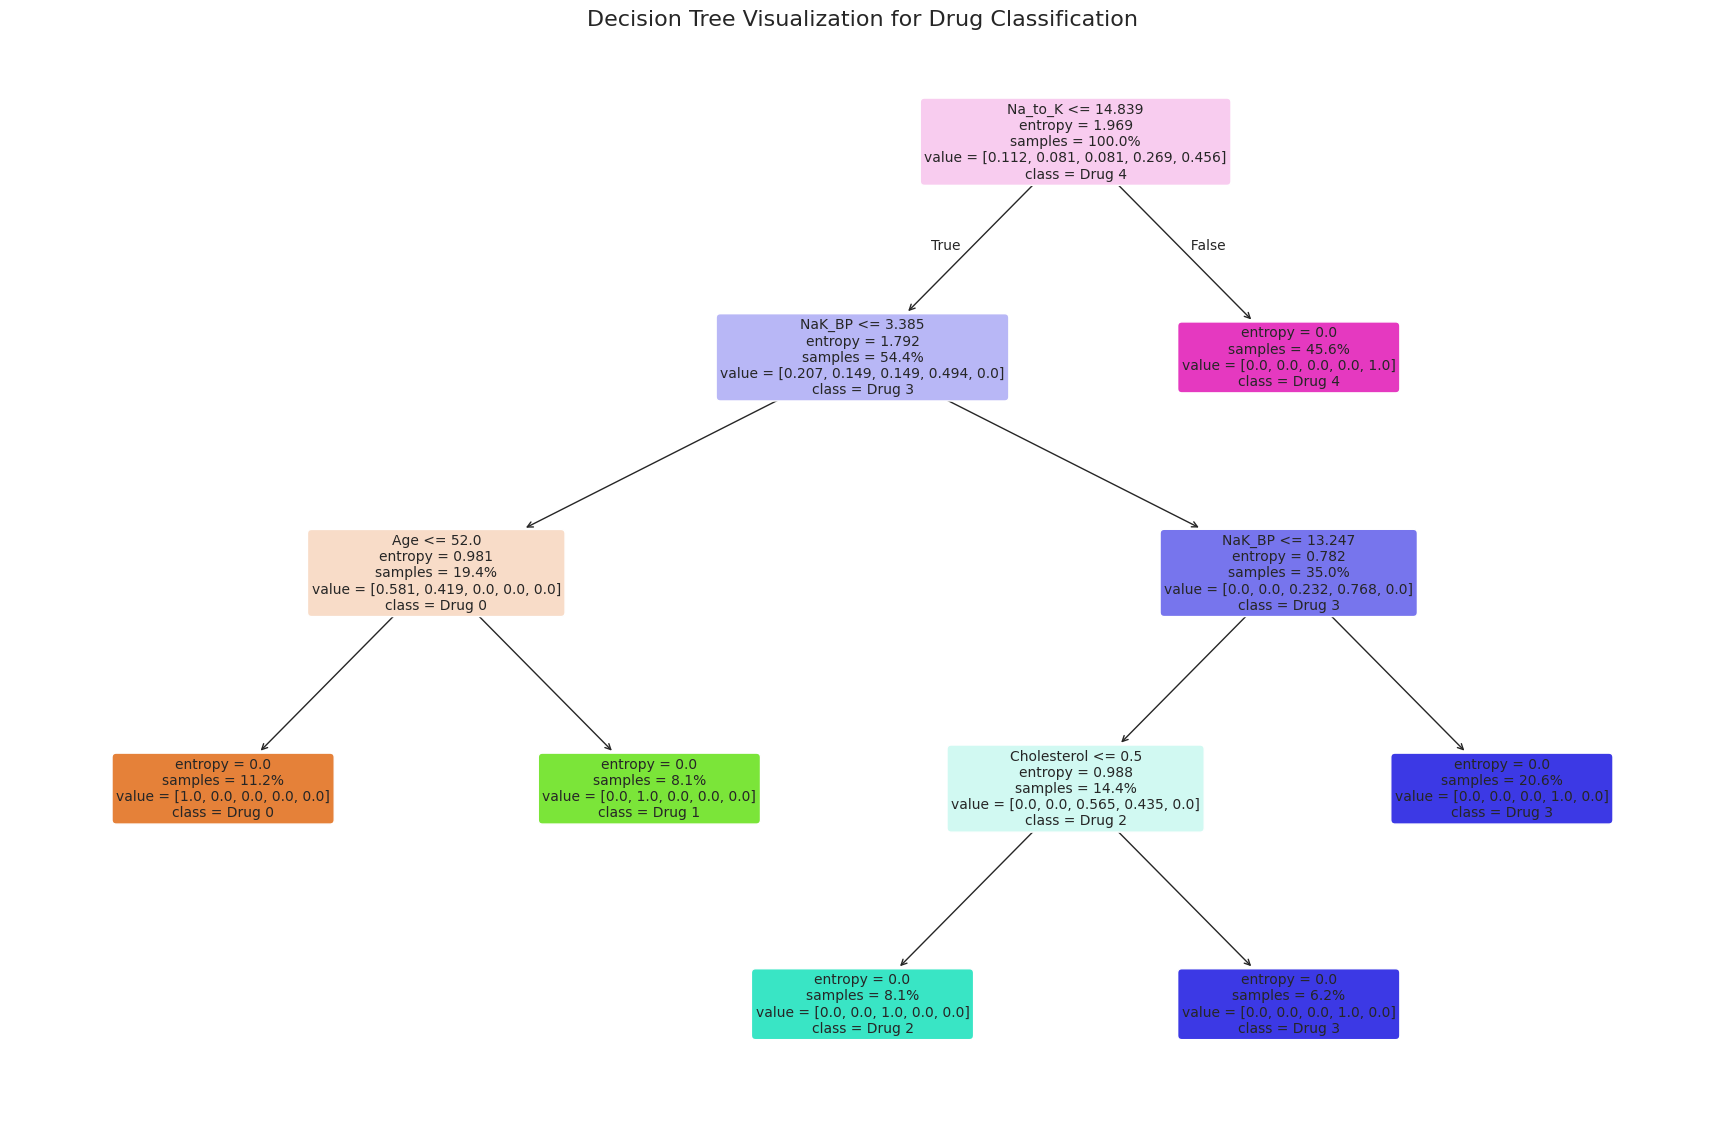

In [25]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 14))

class_labels = [f"Drug {c}" for c in sorted(df_numeric['Drug'].unique())]

tree.plot_tree(
    model,
    feature_names=model.feature_names_in_,
    class_names=class_labels,
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True
)

plt.title("Decision Tree Visualization for Drug Classification", fontsize=16)
plt.show()


random tree

In [26]:
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import time

rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(2, 10),
    'min_samples_split': randint(2, 6),
    'min_samples_leaf': randint(1, 4),
    'class_weight': ['balanced', None],
    'criterion': ['gini', 'entropy']
}

def train_model(model, param_dist):
    start = time.time()
    tscv = TimeSeriesSplit(n_splits=3)

    rand_search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=15,
        scoring='accuracy',
        cv=tscv,
        random_state=42,
        n_jobs=-1
    )

    rand_search.fit(X_train, y_train)

    print("Best hyperparameters:", rand_search.best_params_)
    print(f"Training time: {time.time() - start:.2f} seconds")
    print(f"Best cross-validated accuracy: {rand_search.best_score_:.3f}")

    return rand_search.best_estimator_

model_rf = train_model(rf, param_dist)


Best hyperparameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 124}
Training time: 6.67 seconds
Best cross-validated accuracy: 0.933


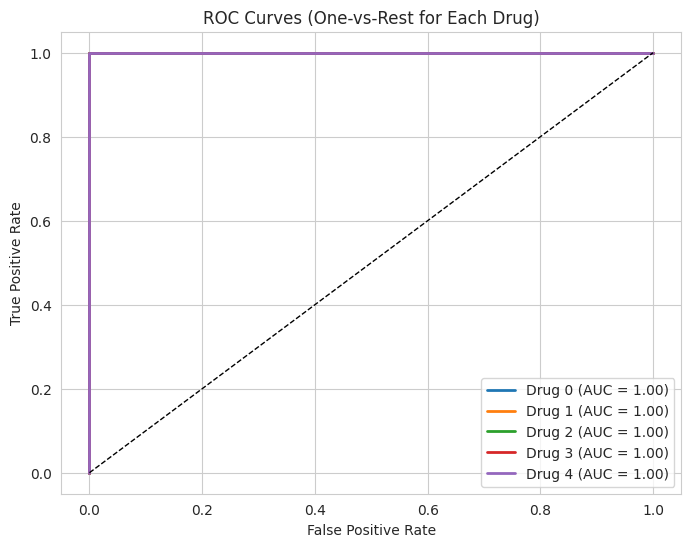

Macro-average ROC-AUC: 1.0
Weighted-average ROC-AUC: 1.0


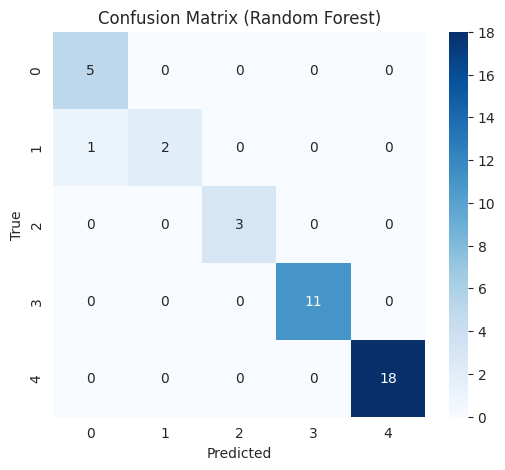

Macro F1-score: 0.942
Weighted F1-score: 0.974

Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00        18

    accuracy                           0.97        40
   macro avg       0.97      0.93      0.94        40
weighted avg       0.98      0.97      0.97        40



In [27]:
from sklearn.metrics import roc_auc_score, roc_curve, auc, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

y_pred = model_rf.predict(X_test)
y_proba = model_rf.predict_proba(X_test)

y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"Drug {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest for Each Drug)")
plt.legend()
plt.show()

print("Macro-average ROC-AUC:", roc_auc_score(y_test_bin, y_proba, average='macro'))
print("Weighted-average ROC-AUC:", roc_auc_score(y_test_bin, y_proba, average='weighted'))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Macro F1-score: {macro_f1:.3f}")
print(f"Weighted F1-score: {weighted_f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


/tmp/ipython-input-348516120.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")


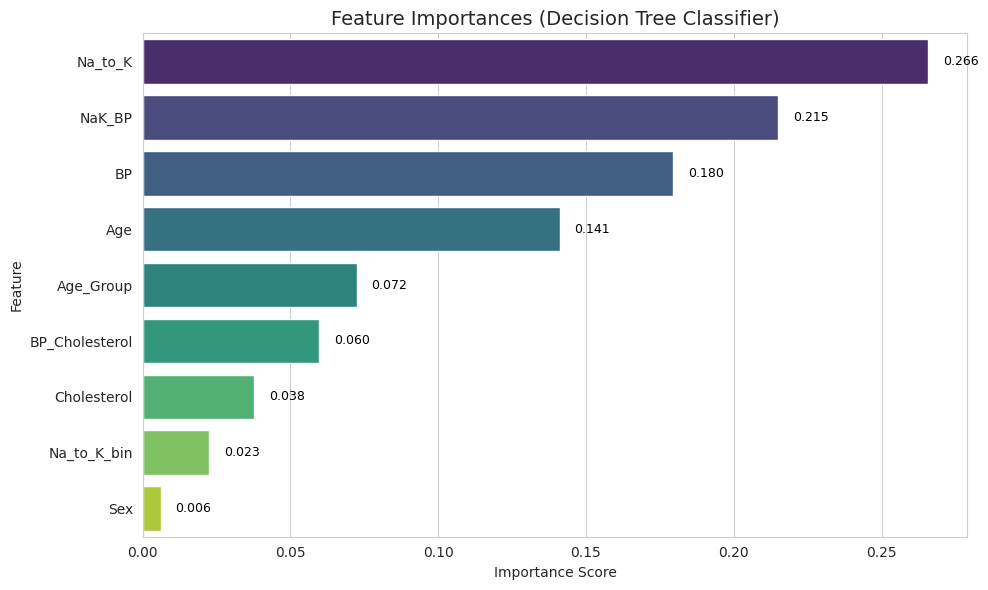


Feature Importance Ranking:
 1. Na_to_K              — 0.2658
 2. NaK_BP               — 0.2151
 3. BP                   — 0.1795
 4. Age                  — 0.1411
 5. Age_Group            — 0.0724
 6. BP_Cholesterol       — 0.0596
 7. Cholesterol          — 0.0377
 8. Na_to_K_bin          — 0.0226
 9. Sex                  — 0.0061


In [28]:
plot_feature_importances(model_rf)


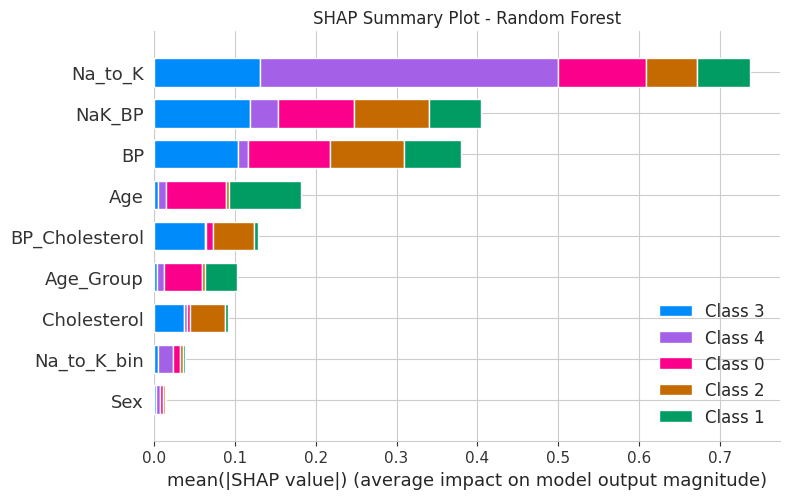

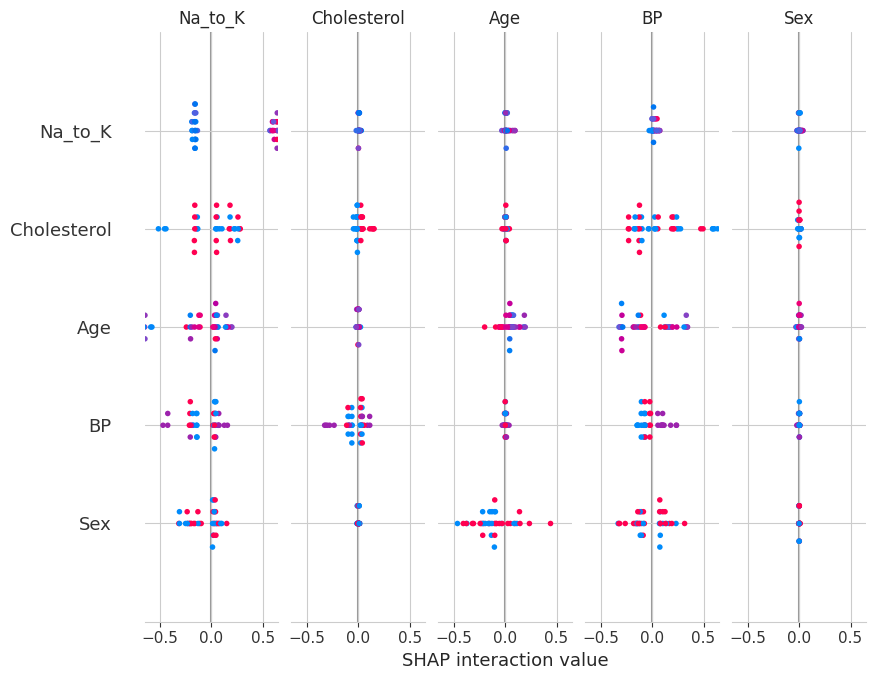

In [29]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X_test)

plt.title("SHAP Summary Plot - Random Forest")
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)
plt.show()

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)
plt.show()


# model Layout

In [30]:
import joblib

model_artifact = {
    "ordered_columns": X_train.columns.tolist(),
    "rf_model": model_rf,
    #"rf_model_threshold": 0.5
}

joblib.dump(model_artifact, "model.joblib")
print("Model saved as model.joblib")


Model saved as model.joblib


In [31]:
import joblib

model_artifact = joblib.load("model.joblib")
features = model_artifact["ordered_columns"]
rf_model = model_artifact["rf_model"]
#model_threshold = model_artifact["rf_model_threshold"]

print("Model loaded successfully.")


Model loaded successfully.


In [32]:
def pre_process(data, features):
    df = pd.DataFrame([data])
    df = df.reindex(columns=features, fill_value=0)
    return df

def run_inference(model, data, features):
    """Simulate production model inference."""
    start = time.time()

    input_data = pre_process(data, features)

    preds = model.predict(input_data)
    probs = model.predict_proba(input_data)

    end = time.time()
    elapsed = (end - start) * 1000
    return preds, probs, elapsed


In [33]:
sample_input = {
    "Age": 45,
    "Sex": 1,
    "BP": 2,
    "Cholesterol": 1,
    "Na_to_K": 14.5,
    "Na_to_K_bin": 2,
    "Age_Group": 1,
    "BP_Cholesterol": 0.6,
    "NaK_BP": 15.2
}

preds, probs, elapsed = run_inference(rf_model, sample_input, features)

print(f"Predicted class: {preds[0]}")
print(f"Class probabilities: {probs[0]}")
print(f"Inference time: {elapsed:.3f} ms")


Predicted class: 3
Class probabilities: [0.         0.         0.00806452 0.88597513 0.10596035]
Inference time: 34.374 ms


In [34]:
import numpy as np

times = []
for _ in range(100):
    _, _, elapsed = run_inference(rf_model, sample_input, features)
    times.append(elapsed)

print(f"Average inference time: {np.mean(times):.3f} ms")
print(f"Fastest: {np.min(times):.3f} ms | Slowest: {np.max(times):.3f} ms")


Average inference time: 23.317 ms
Fastest: 17.075 ms | Slowest: 47.524 ms


In [35]:
import numpy as np
import pandas as pd
import time

n_samples = 1000
batch_data = pd.DataFrame({
    "Age": np.random.randint(15, 80, n_samples),
    "Sex": np.random.randint(0, 2, n_samples),
    "BP": np.random.randint(0, 3, n_samples),
    "Cholesterol": np.random.randint(0, 2, n_samples),
    "Na_to_K": np.random.uniform(5, 40, n_samples),
    "Na_to_K_bin": np.random.randint(0, 3, n_samples),
    "Age_Group": np.random.randint(0, 4, n_samples),
    "BP_Cholesterol": np.random.uniform(0, 2, n_samples),
    "NaK_BP": np.random.uniform(5, 40, n_samples)
})

batch_data = batch_data.reindex(columns=features)

start_time = time.time()
batch_preds = rf_model.predict(batch_data)
batch_probs = rf_model.predict_proba(batch_data)
end_time = time.time()

total_time = (end_time - start_time) * 1000
avg_time_per_sample = total_time / n_samples
throughput = n_samples / (end_time - start_time)

print(f"Batch size: {n_samples}")
print(f"Total inference time: {total_time:.2f} ms")
print(f"Avg time per sample: {avg_time_per_sample:.3f} ms")
print(f"Throughput: {throughput:.2f} samples/second")


Batch size: 1000
Total inference time: 28.35 ms
Avg time per sample: 0.028 ms
Throughput: 35272.04 samples/second
